# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

df = pd.read_csv("../data/hillstrom_email_data.csv")

In [ ]:
print(df.shape)

(64000, 12)


In [ ]:
print(df.dtypes)

recency              int64
history_segment     object
history            float64
mens                 int64
womens                int64
zip_code            object
newbie               int64
channel              object
segment              object
visit                int64
conversion            int64
spend               float64
dtype: object


In [ ]:
print(df.isnull().sum())

recency             0
history_segment     0
history             0
mens                0
womens              0
zip_code            0
newbie              0
channel             0
segment             0
visit               0
conversion          0
spend               0
dtype: int64


In [ ]:
print(df["segment"].value_counts(dropna=False))
print("\nn_unique segment values:", df["segment"].nunique(dropna=False))

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

n_unique segment values: 3


In [6]:
covariates_numeric = ["recency", "history", "mens", "womens"]
covariates_categorical = ["zip_code", "newbie", "channel"]
outcomes = ["visit", "conversion", "spend"]

print(df[covariates_numeric].describe())

            recency       history          mens        womens
count  64000.000000  64000.000000  64000.000000  64000.000000
mean       5.763734    242.085656      0.551031      0.549719
std        3.507592    256.158608      0.497393      0.497526
min        1.000000     29.990000      0.000000      0.000000
25%        2.000000     64.660000      0.000000      0.000000
50%        6.000000    158.110000      1.000000      1.000000
75%        9.000000    325.657500      1.000000      1.000000
max       12.000000   3345.930000      1.000000      1.000000


In [7]:
for col in covariates_categorical:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- zip_code ---
zip_code
Surburban    28776
Urban        25661
Rural         9563
Name: count, dtype: int64

--- newbie ---
newbie
1    32144
0    31856
Name: count, dtype: int64

--- channel ---
channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64


In [8]:
print(df[outcomes].describe())

              visit    conversion         spend
count  64000.000000  64000.000000  64000.000000
mean       0.146781      0.009031      1.050908
std        0.353890      0.094604     15.036448
min        0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000
50%        0.000000      0.000000      0.000000
75%        0.000000      0.000000      0.000000
max        1.000000      1.000000    499.000000


In [9]:
print("visit rate:", df["visit"].mean())
print("conversion rate:", df["conversion"].mean())
print("spend mean (all rows):", df["spend"].mean())
converters = df[df["conversion"] == 1]
print("spend mean (converters only), n =", len(converters), ":", converters["spend"].mean())

visit rate: 0.14678125
conversion rate: 0.00903125
spend mean (all rows): 1.05090828125
spend mean (converters only), n = 578 : 116.36354671280277


In [10]:
print("n duplicate rows:", df.duplicated().sum())

n duplicate rows: 6562


### Checking Duplicate

In [ ]:
outcomes = ["visit", "conversion", "spend"]
covariate_cols = [c for c in df.columns if c not in outcomes]

full_dup_mask = df.duplicated(keep=False)
cov_dup_mask = df.duplicated(subset=covariate_cols, keep=False)


coincidental_mask = cov_dup_mask & (~full_dup_mask)

print("covariate columns used:", covariate_cols)
print()
print("full-row duplicates, all occurrences (keep=False):", full_dup_mask.sum())
print("covariate-profile duplicates, all occurrences (keep=False):", cov_dup_mask.sum())
print()
print("true duplicates (identical covariates AND outcomes):", full_dup_mask.sum())
print("coincidental collisions (identical covariates, different outcomes):", coincidental_mask.sum())
print()
print("sanity check: true + coincidental == covariate-profile duplicates:", full_dup_mask.sum() + coincidental_mask.sum() == cov_dup_mask.sum())

covariate columns used: ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment']

full-row duplicates, all occurrences (keep=False): 7634
covariate-profile duplicates, all occurrences (keep=False): 8001

true duplicates (identical covariates AND outcomes): 7634
coincidental collisions (identical covariates, different outcomes): 367

sanity check -- true + coincidental == covariate-profile duplicates: True


### True-duplicate distribution across segment arms

In [12]:
arm_totals = df["segment"].value_counts()
arm_dup_counts = df.loc[full_dup_mask, "segment"].value_counts()

dup_by_arm = pd.DataFrame({
    "total_rows": arm_totals,
    "true_dup_rows": arm_dup_counts
}).fillna(0)
dup_by_arm["true_dup_rows"] = dup_by_arm["true_dup_rows"].astype(int)
dup_by_arm["pct_of_arm"] = (dup_by_arm["true_dup_rows"] / dup_by_arm["total_rows"] * 100).round(3)
dup_by_arm = dup_by_arm.sort_index()

print(dup_by_arm)
print()
print("overall true dup rate:", round(full_dup_mask.sum() / len(df) * 100, 3), "%")

               total_rows  true_dup_rows  pct_of_arm
segment                                             
Mens E-Mail         21307           2504      11.752
No E-Mail           21306           2555      11.992
Womens E-Mail       21387           2575      12.040

overall true dup rate: 11.928 %


## Categorical Check & Outcome Column

In [13]:
for col in ["zip_code", "channel"]:
    s = df[col]
    print(f"--- {col} ---")
    print("unique values:", sorted(s.unique().tolist()))
    print("n_unique:", s.nunique())
    print("rows where value != stripped value (whitespace issue):", (s != s.str.strip()).sum())
    print("n_unique after lowercasing:", s.str.lower().nunique())
    print("value_counts sum == len(df):", s.value_counts().sum() == len(df))
    print("dtype:", s.dtype)
    print()

--- zip_code ---
unique values: ['Rural', 'Surburban', 'Urban']
n_unique: 3
rows where value != stripped value (whitespace issue): 0
n_unique after lowercasing: 3
value_counts sum == len(df): True
dtype: object

--- channel ---
unique values: ['Multichannel', 'Phone', 'Web']
n_unique: 3
rows where value != stripped value (whitespace issue): 0
n_unique after lowercasing: 3
value_counts sum == len(df): True
dtype: object



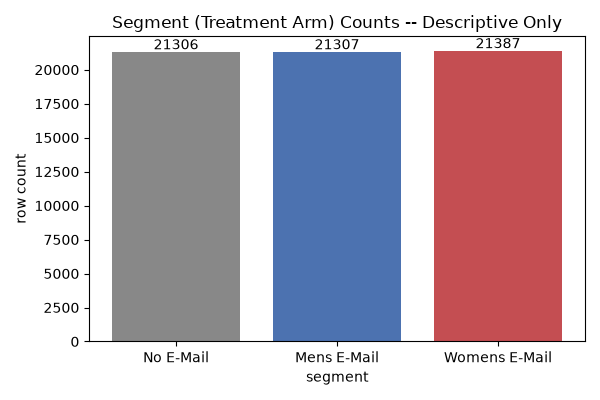

In [ ]:
import matplotlib.pyplot as plt

arm_order = ["No E-Mail", "Mens E-Mail", "Womens E-Mail"]
counts = df["segment"].value_counts().reindex(arm_order)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=["#888888", "#4C72B0", "#C44E52"])
ax.set_title("Segment (Treatment Arm) Counts: Descriptive Only")
ax.set_xlabel("segment")
ax.set_ylabel("row count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, str(v), ha="center")
fig.tight_layout()
plt.show()

In [15]:
by_arm = df.groupby("segment", observed=True).agg(
    n=("segment", "size"),
    visit_rate=("visit", "mean"),
    conversion_rate=("conversion", "mean"),
    avg_spend=("spend", "mean"),
).reindex(arm_order)

print(by_arm)

                   n  visit_rate  conversion_rate  avg_spend
segment                                                     
No E-Mail      21306    0.106167         0.005726   0.652789
Mens E-Mail    21307    0.182757         0.012531   1.422617
Womens E-Mail  21387    0.151400         0.008837   1.077202


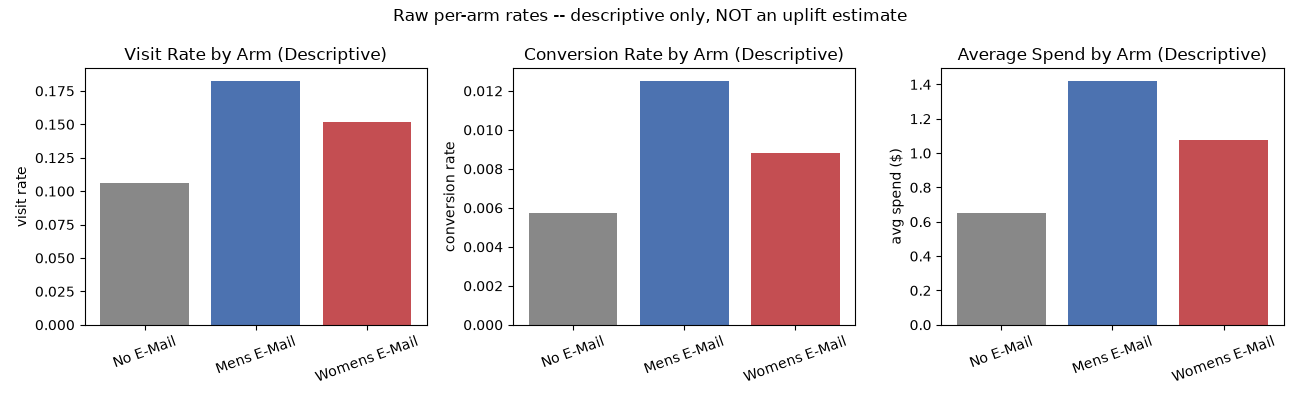

In [ ]:
colors = ["#888888", "#4C72B0", "#C44E52"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(by_arm.index, by_arm["visit_rate"], color=colors)
axes[0].set_title("Visit Rate by Arm (Descriptive)")
axes[0].set_ylabel("visit rate")

axes[1].bar(by_arm.index, by_arm["conversion_rate"], color=colors)
axes[1].set_title("Conversion Rate by Arm (Descriptive)")
axes[1].set_ylabel("conversion rate")

axes[2].bar(by_arm.index, by_arm["avg_spend"], color=colors)
axes[2].set_title("Average Spend by Arm (Descriptive)")
axes[2].set_ylabel("avg spend ($)")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Raw per-arm rates: NOT an uplift estimate")
fig.tight_layout()
plt.show()